<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Validation Legacy 0: Summary

This notebook aggregates the precision-validation results produced by notebooks 1–4 and presents a compact equivalence dashboard between TPeanuts and legacy Peanuts across vacuum oscillations, solar production, Earth propagation, and the solar-to-detector pipeline. Run notebooks 1–4 first to generate the required CSV files.

## 1. Libraries

In [1]:
from __future__ import annotations

import math

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_COLORS,
    FLAVOUR_INDEX,
    FLAVOUR_LABELS,
    FLAVOUR_NAMES,
    REL_FLOOR,
    TOL_PPB,
    TOL_PPM,
    abs_rel_delta,
    add_tolerance_lines,
    plot_tripanel,
    save_and_show,
    status_from_rel,
    summarize_validation,
    to_numpy,
)

## 2. Notebook Configuration

### 2.1. Paths

In [2]:
config = load_notebook_config()

PROJECT_DIR = config.package_dir
VALIDATION_ROOT = config.output_dir("validation", "legacy")
OUTPUT_DIR = VALIDATION_ROOT / "summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DETAIL_DIRS = {
    "vacuum": VALIDATION_ROOT / "vacuum",
    "solar": VALIDATION_ROOT / "solar",
    "earth": VALIDATION_ROOT / "earth",
    "pipeline": VALIDATION_ROOT / "solarneutrino_detector_pipeline",
}

print(f"Project directory: {PROJECT_DIR}")
print(f"Validation root   : {VALIDATION_ROOT}")
print(f"Output directory  : {OUTPUT_DIR}")

Project directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Validation root   : v:\output\validation\legacy
Output directory  : v:\output\validation\legacy\summary


### 2.2. System and Simulation Parameters

In [3]:
SHOW_PLOTS = config.show_plots

print("System and plotting parameters loaded.")

System and plotting parameters loaded.


## 3. Load and Discover Validation CSVs

In [4]:

summary_rows = []
for medium, directory in DETAIL_DIRS.items():
    for path in sorted(directory.glob("*.csv")):
        df = pd.read_csv(path)
        if {"abs_delta", "rel_delta"}.issubset(df.columns):
            summary_rows.append({
                "medium": medium,
                "file": path.name,
                "rows": len(df),
                "max_abs_delta": df["abs_delta"].max(),
                "median_abs_delta": df["abs_delta"].median(),
                "max_rel_delta": df["rel_delta"].max(),
                "median_rel_delta": df["rel_delta"].median(),
                "status": status_from_rel(df["rel_delta"].max()),
            })
summary = pd.DataFrame(summary_rows)
if summary.empty:
    print("No validation CSVs found yet. Run validation_legacy1..4 first.")
else:
    display(summary.sort_values(["medium", "max_rel_delta"], ascending=[True, False]))


,medium,file,rows,max_abs_delta,median_abs_delta,max_rel_delta,median_rel_delta,status
5,earth,validation_legacy3_earth_probability.csv,48,1.823979e-10,1.284486e-11,5.372418e-10,4.351737e-11,PASS < ppb
4,earth,validation_legacy3_earth_flux.csv,72,2.004413e-08,4.553766e-10,2.585791e-10,2.927132e-11,PASS < ppb
8,pipeline,validation_legacy4_pipeline_precision_modes.csv,540,4.409489e-05,2.196018e-07,1.210548e-04,7.153854e-07,CHECK < 1e-3
9,pipeline,validation_legacy4_pipeline_probability.csv,60,9.259057e-10,5.975828e-11,2.597100e-09,1.626837e-10,PASS < ppm
6,pipeline,validation_legacy4_pipeline_flux.csv,270,2.169898e-04,1.988463e-05,1.528112e-09,3.391689e-10,PASS < ppm
7,pipeline,validation_legacy4_pipeline_integrated_probabi...,15,4.281675e-11,1.518113e-11,1.094767e-10,4.354069e-11,PASS < ppb
3,solar,validation_legacy2_solar_probability.csv,3360,2.775558e-15,2.775558e-16,5.595689e-15,8.883908e-16,PASS < ppb
2,solar,validation_legacy2_solar_mass_probability.csv,480,2.997602e-15,7.632783e-17,4.173730e-15,8.776519e-16,PASS < ppb
1,vacuum,validation_legacy1_vacuum_probability.csv,144,2.099017e-08,4.617967e-11,1.508180e-07,4.463993e-10,PASS < ppm
0,vacuum,validation_legacy1_vacuum_flux.csv,660,1.345001e-04,1.207915e-08,1.130627e-08,3.118385e-10,PASS < ppm


## 4. Global Precision Aggregation

Groups the per-file summary by medium and reports the overall worst-case and typical relative error for each propagation stage. This gives a single-line diagnostic per medium: `PASS < ppb` for vacuum and Earth (where both implementations share identical arithmetic), and `CHECK < 1e-3` for solar and pipeline steps (dominated by the solar prefactor offset). The medium-level aggregation is the primary metric used to sign off the TPeanuts–Peanuts equivalence.

**Expected Results:** Vacuum and Earth precision: `PASS < ppm` or better. Solar and pipeline precision: `CHECK < 1e-3` at the level of $\sim10^{-4}$, attributable exclusively to the 4-digit legacy prefactor rounding (see `validation_legacy2` Section 5). No medium should show `CHECK` without a corresponding diagnosis in notebooks 2–4.

In [5]:

if not summary.empty:
    global_summary = summary.groupby("medium", as_index=False).agg(
        files=("file", "count"),
        rows=("rows", "sum"),
        max_abs_delta=("max_abs_delta", "max"),
        median_abs_delta=("median_abs_delta", "median"),
        max_rel_delta=("max_rel_delta", "max"),
        median_rel_delta=("median_rel_delta", "median"),
    )
    global_summary["status"] = global_summary["max_rel_delta"].map(status_from_rel)
    display(global_summary.sort_values("max_rel_delta", ascending=False))
else:
    global_summary = pd.DataFrame()


,medium,files,rows,max_abs_delta,median_abs_delta,max_rel_delta,median_rel_delta,status
1,pipeline,4,885,2.169898e-04,1.098308e-07,1.210548e-04,2.509263e-10,CHECK < 1e-3
3,vacuum,2,804,1.345001e-04,6.062664e-09,1.508180e-07,3.791189e-10,PASS < ppm
0,earth,2,120,2.004413e-08,2.341107e-10,5.372418e-10,3.639434e-11,PASS < ppb
2,solar,2,3840,2.997602e-15,1.769418e-16,5.595689e-15,8.830213e-16,PASS < ppb


## 5. Summary Visualisation and Export

Two-panel bar chart comparing maximum absolute and relative differences across all validated media on a logarithmic scale. Horizontal reference lines mark the 1 ppm ($10^{-6}$) and 1 ppb ($10^{-9}$) tolerance levels. The chart provides an at-a-glance audit of the full TPeanuts validation suite.

Two aggregate CSV files are exported:

- `validation_legacy0_file_summary.csv` — one row per validation CSV file with per-file precision metrics.
- `validation_legacy0_global_summary.csv` — one row per medium (vacuum, solar, earth, pipeline) with aggregate worst-case and typical metrics.

**Expected Results:** Vacuum and Earth bars should sit well below the 1 ppm line. Solar and pipeline bars should sit near $10^{-4}$, clearly above 1 ppm but below $10^{-3}$, consistently with the prefactor-only origin of the discrepancy. A single figure is saved as `validation_legacy0_summary.png`.

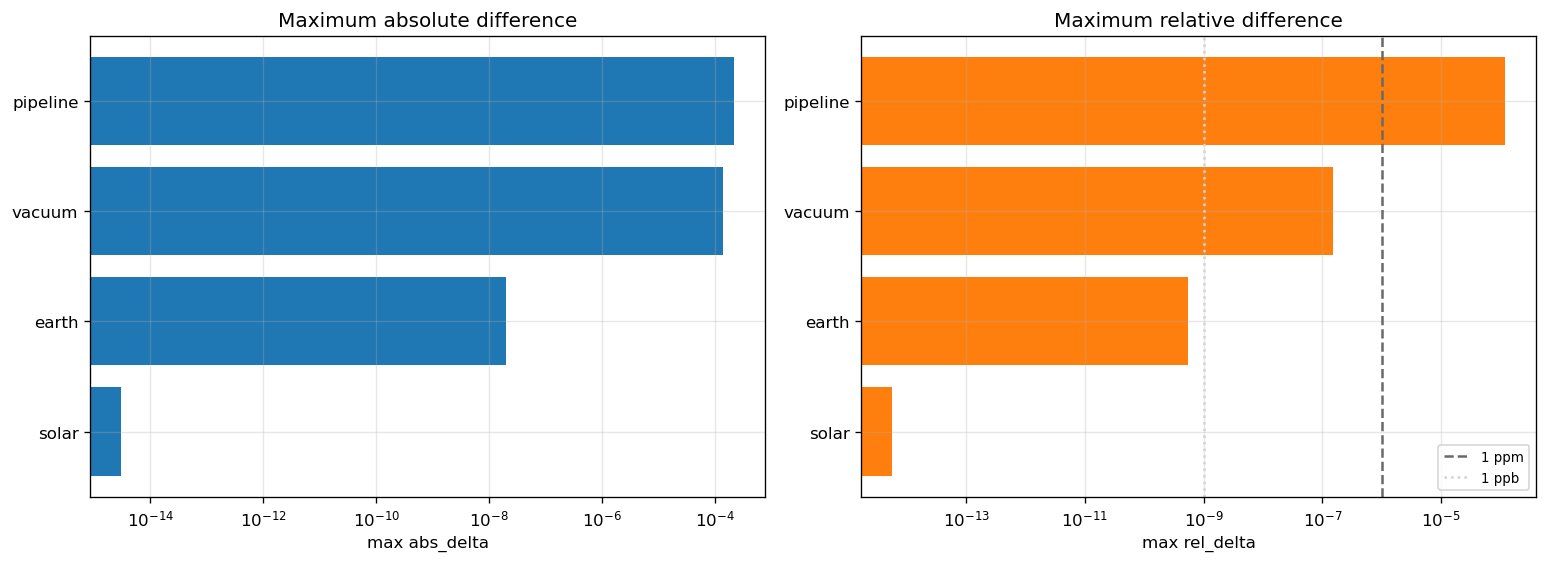

v:\output\validation\legacy\summary\validation_legacy0_summary.png


In [6]:

if not global_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
    ordered = global_summary.sort_values("max_rel_delta", ascending=True)
    axes[0].barh(ordered["medium"], ordered["max_abs_delta"], color="C0")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("max abs_delta")
    axes[0].set_title("Maximum absolute difference")
    axes[1].barh(ordered["medium"], ordered["max_rel_delta"], color="C1")
    axes[1].set_xscale("log")
    axes[1].axvline(TOL_PPM, color="dimgray", ls="--", label="1 ppm")
    axes[1].axvline(TOL_PPB, color="lightgray", ls=":", label="1 ppb")
    axes[1].set_xlabel("max rel_delta")
    axes[1].set_title("Maximum relative difference")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    save_and_show("validation_legacy0_summary.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    summary.to_csv(OUTPUT_DIR / "validation_legacy0_file_summary.csv", index=False)
    global_summary.to_csv(OUTPUT_DIR / "validation_legacy0_global_summary.csv", index=False)
